## Stepan-VORONYI-Camp-2026
# Hometask lesson 4:Logistic Regression

## Import necessary packages

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer, make_moons, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import accuracy_score, precision_recall_curve, recall_score, f1_score, classification_report

## Load Dataset

In [7]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print("X shape:", X.shape)
print("y shape:", y.shape)
print(y.value_counts())

X shape: (569, 30)
y shape: (569,)
1    357
0    212
Name: count, dtype: int64


## Train-Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (455, 30)
Test: (114, 30)


## Task 1: Compare models with StandartScaler and without him

In [13]:
print("Model without StandartScaler")
log_reg_unscaled = LogisticRegression(max_iter=10000, random_state=42)

start_time = time.time()
log_reg_unscaled.fit(X_train, y_train)
time_unscaled = time.time() - start_time

y_pred_unscaled = log_reg_unscaled.predict(X_test)
acc_unscaled = accuracy_score(y_test, y_pred_unscaled)

print(f"Training time: {time_unscaled:.4f} sec")
print(f"Accuracy: {acc_unscaled:.4f}")


print("Model with StandardScaler")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg_scaled = LogisticRegression(max_iter=1000, random_state=42)

start_time = time.time()
log_reg_scaled.fit(X_train_scaled, y_train)
time_scaled = time.time() - start_time

y_pred_scaled = log_reg_scaled.predict(X_test_scaled)
acc_scaled = accuracy_score(y_test, y_pred_scaled)

print(f"Training time: {time_scaled:.4f} sec")
print(f"Accuracy: {acc_scaled:.4f}")

print("CONCLUSION")
if time_scaled < time_unscaled:
    print("The scaled model learned faster")
if acc_scaled >= acc_unscaled:
    print("The scaled model showed better accuracy!")

Model without StandartScaler
Training time: 1.0051 sec
Accuracy: 0.9649
Model with StandardScaler
Training time: 0.0070 sec
Accuracy: 0.9825
CONCLUSION
The scaled model learned faster
The scaled model showed better accuracy!


## Task 2: For Logistic Regression, choose the threshold that maximizes recall instead of F1.

In [11]:
y_scores = log_reg_scaled.predict_proba(X_test_scaled)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)

print("Standard threshold (0.5)")
y_pred_default = log_reg_scaled.predict(X_test_scaled) 
print(f"Recall:    {recall_score(y_test, y_pred_default):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_default):.4f}")

high_recall_indices = np.where(recalls[:-1] >= 0.99)[0]
best_idx = high_recall_indices[-1] 

custom_threshold = thresholds[best_idx]
print(f"\nNew threshold found: {custom_threshold:.4f} ---")

y_pred_custom = (y_scores >= custom_threshold).astype(int)
print(f"New Recall:    {recall_score(y_test, y_pred_custom):.4f}")
print(f"New F1 Score:  {f1_score(y_test, y_pred_custom):.4f}")

Standard threshold (0.5)
Recall:    0.9861
F1 Score:  0.9861

New threshold found: 0.3659 ---
New Recall:    1.0000
New F1 Score:  0.9931


## Visualisation

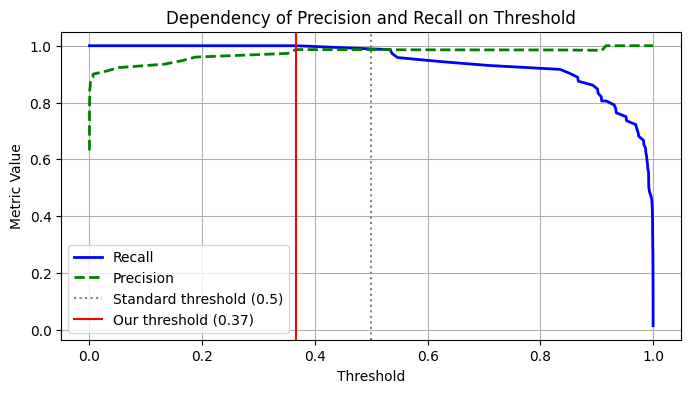

In [12]:
plt.figure(figsize=(8, 4))
plt.plot(thresholds, recalls[:-1], 'b-', label='Recall', linewidth=2)
plt.plot(thresholds, precisions[:-1], 'g--', label='Precision', linewidth=2)
plt.axvline(x=0.5, color='gray', linestyle=':', label='Standard threshold (0.5)')
plt.axvline(x=custom_threshold, color='red', linestyle='-', label=f'Our threshold ({custom_threshold:.2f})')
plt.xlabel('Threshold')
plt.ylabel('Metric Value')
plt.title('Dependency of Precision and Recall on Threshold')
plt.legend()
plt.grid(True)
plt.show()

## Task 3: On make_moons, try a denser grid of gamma values and watch the boundary overfit.

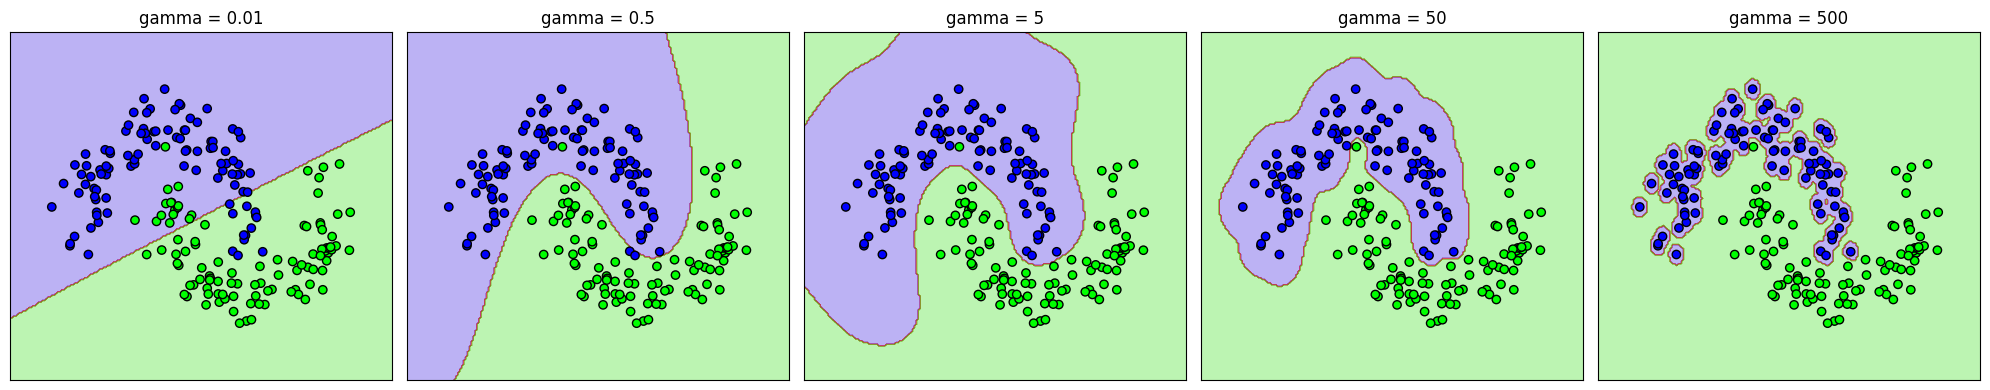

In [15]:
from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(n_samples=200, noise=0.15, random_state=42)
gamma_values = [0.01, 0.5, 5, 50, 500] 
fig, axes = plt.subplots(1, len(gamma_values), figsize=(20, 4))

def plot_svm_boundary(clf, X, y, ax, title):
    clf.fit(X, y)

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.brg)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.brg, edgecolors='k')
    ax.set_title(title)
    ax.set_xticks(())
    ax.set_yticks(())

for ax, g in zip(axes, gamma_values):

    svm_clf = SVC(kernel="rbf", gamma=g, C=10)
    plot_svm_boundary(svm_clf, X_moons, y_moons, ax, title=f"gamma = {g}")

plt.tight_layout()
plt.show()

## Task 4: Add class_weight="balanced" and test what changes on imbalanced synthetic data.

In [16]:
from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix, recall_score, precision_score

X_imb, y_imb = make_classification(n_samples=2000, n_features=10, 
                                   weights=[0.95, 0.05], random_state=42)

X_tr_imb, X_te_imb, y_tr_imb, y_te_imb = train_test_split(X_imb, y_imb, test_size=0.3, random_state=42)

print(f"Amount of Class 1 (rare) in the test set: {sum(y_te_imb == 1)} out of {len(y_te_imb)}")

Amount of Class 1 (rare) in the test set: 39 out of 600


## Train default model and balanced one

In [17]:
lr_normal = LogisticRegression(random_state=42)
lr_normal.fit(X_tr_imb, y_tr_imb)
y_pred_normal = lr_normal.predict(X_te_imb)

lr_balanced = LogisticRegression(class_weight="balanced", random_state=42)
lr_balanced.fit(X_tr_imb, y_tr_imb)
y_pred_balanced = lr_balanced.predict(X_te_imb)

## Compare results

In [20]:
results = pd.DataFrame({
    'Metric (for Class 1)': ['Recall ', 'Precision ', 'Overall Accuracy'],
    'Standard Model': [
        recall_score(y_te_imb, y_pred_normal),
        precision_score(y_te_imb, y_pred_normal, zero_division=0),
        accuracy_score(y_te_imb, y_pred_normal)
    ],
    'Balanced Model': [
        recall_score(y_te_imb, y_pred_balanced),
        precision_score(y_te_imb, y_pred_balanced, zero_division=0),
        accuracy_score(y_te_imb, y_pred_balanced)
    ]
})

print("\nComparison of Results")
print(results.to_string(index=False))

print("\nConfusion Matrix (Standard Model):")
print(confusion_matrix(y_te_imb, y_pred_normal))
print("\nConfusion Matrix (Balanced Model):")
print(confusion_matrix(y_te_imb, y_pred_balanced))


Comparison of Results
Metric (for Class 1)  Standard Model  Balanced Model
             Recall         0.512821        0.948718
          Precision         0.769231        0.370000
    Overall Accuracy        0.958333        0.891667

Confusion Matrix (Standard Model):
[[555   6]
 [ 19  20]]

Confusion Matrix (Balanced Model):
[[498  63]
 [  2  37]]


## Visualisation of confusion Matrix

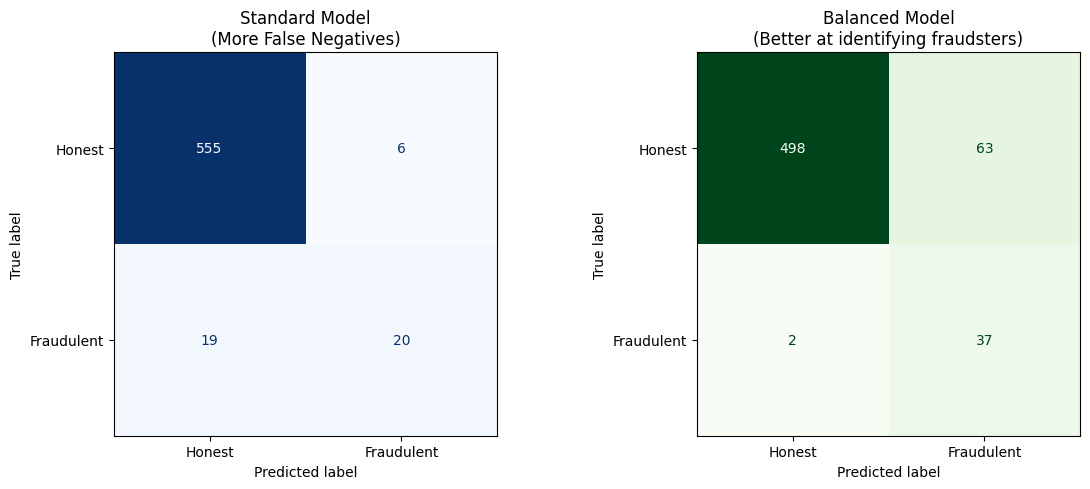

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

cm_normal = confusion_matrix(y_te_imb, y_pred_normal)
disp_normal = ConfusionMatrixDisplay(confusion_matrix=cm_normal, display_labels=['Honest', 'Fraudulent'])
disp_normal.plot(ax=ax1, cmap='Blues', colorbar=False)
ax1.set_title("Standard Model\n(More False Negatives)")

cm_balanced = confusion_matrix(y_te_imb, y_pred_balanced)
disp_balanced = ConfusionMatrixDisplay(confusion_matrix=cm_balanced, display_labels=['Honest', 'Fraudulent'])
disp_balanced.plot(ax=ax2, cmap='Greens', colorbar=False)
ax2.set_title("Balanced Model\n(Better at identifying fraudsters)")

plt.tight_layout()
plt.show()

## Task 5:Compare LinearSVC and SVC(kernel="linear") on runtime and quality.

In [22]:
X_large, y_large = make_classification(n_samples=20000, n_features=20, random_state=42)
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X_large, y_large, test_size=0.2, random_state=42)

scaler_l = StandardScaler()
X_train_l = scaler_l.fit_transform(X_train_l)
X_test_l = scaler_l.transform(X_test_l)

## Test Linear SVC

In [24]:
lsvc = LinearSVC(max_iter=10000, random_state=42)
start = time.time()
lsvc.fit(X_train_l, y_train_l)
time_lsvc = time.time() - start
acc_lsvc = lsvc.score(X_test_l, y_test_l)

print(f"--- LinearSVC ---")
print(f"Time of Training: {time_lsvc:.4f} sec")
print(f"Accuracy: {acc_lsvc:.4f}")

--- LinearSVC ---
Time of Training: 0.0390 sec
Accuracy: 0.8785


## Test SVC(kernel='linear')

In [25]:
svc_lin = SVC(kernel="linear", random_state=42)
start = time.time()
svc_lin.fit(X_train_l, y_train_l)
time_svc_lin = time.time() - start
acc_svc_lin = svc_lin.score(X_test_l, y_test_l)

print(f"\n--- SVC(kernel='linear') ---")
print(f"Time of Training: {time_svc_lin:.4f} sec")
print(f"Accuracy:     {acc_svc_lin:.4f}")


--- SVC(kernel='linear') ---
Time of Training: 7.9301 sec
Accuracy:     0.8805


Conclusion: So as we can see The Linear SVC is much faster than SVC(kernel='linear') though acuracy is slightly better on the second one but difference in time is absurd and it is much more appealing and productive to use Linear SVC